The purpose of this notebook is to globally fit the aggregated Ba133 calibration data while constraining the widths of the peaks such that they follow expected Fano noise behavior. 

Last updated 2025-11-02 by Niharika Godbole

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.signal import convolve
from scipy.optimize import least_squares

In [2]:
data_dir = Path(r"C:\Users\ngodbole\OneDrive - NASA\Desktop\analysis/data")

In [3]:
def background(E, L_low, L_high, E0, w):
    """Smooth step background model for gamma spectra."""
    return L_high + (L_low - L_high) / (1 + np.exp((E - E0)/w))


def exp_background(x, amp, tau, c):
    """Function to model an exponentially decaying background."""
    return amp * np.exp(-x / tau) + c


def poly_exp_background(x, amp, tau, c, a1, a2):
    """Function to model an exponentially decaying background + polynomial background."""
    exp_term = amp * np.exp(-x / tau) + c
    poly_term = a1 * x + a2 * x**2

    return exp_term + poly_term


def step_background(x, amp_step, edge_energy, width):
    """Step function background for Compton-like features."""
    return amp_step * 0.5 * (1 + np.tanh((edge_energy - x) / width))


def enhanced_background(x, amp, tau, c, a1, a2, step_amp, step_edge, step_width):
    """Function that combines exponentially decaying + polynomial + step function background."""
    base = poly_exp_background(x, amp, tau, c, a1, a2)
    step = step_background(x, step_amp, step_edge, step_width)

    return base + step


def gaussian(x, amp, mu, sigma):
    """Function to model Gaussian peak."""
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def crystal_ball_phys(x, amp, mu, sigma, alpha, n):
    """Function to model Crystal Ball peak. This type of distribution accounts for a Gaussian peak + power-law tailing."""
    t = (x - mu) / sigma
    abs_alpha = np.abs(alpha)
    y = np.zeros_like(x)
    
    # Gaussian core. 
    mask_core = t > -abs_alpha
    y[mask_core] = np.exp(-0.5 * t[mask_core] ** 2)

    # Power-law tail. 
    mask_tail = ~mask_core
    if np.any(mask_tail):
        A = (n / abs_alpha) ** n * np.exp(-0.5 * abs_alpha ** 2)
        B = n / abs_alpha - abs_alpha
        # Avoid negative base for fractional powers. 
        safe_term = np.clip(B - t[mask_tail], 1e-12, None)
        y[mask_tail] = A * safe_term ** (-n)

    return amp * y


def fano_sigma(mu, enc):
    """Function to model the energy resolution (Fano + electronic noise contributions) as a function of energy."""
    Eps = 4.43  # [eV] # Average energy to create an electron hole pair in CdTe. 
    F = 0.15    # Fano factor for CdTe. 
    mu = np.asarray(mu)
    sigma_keV = np.sqrt((Eps * F * mu * 1000.0) + (Eps * enc) ** 2) / 1000.0
    
    return sigma_keV


def residuals(params, x, y, config, weights=None):
    """Compute the residuals for the least-squares function."""
    r = composite_model(x, params, config) - y
    if weights is not None:
        r = r * weights
    
    return r


def composite_model(x, params, config):
    idx = 0
    y = np.zeros_like(x)

    # Setup the background model to use. 
    if config.get("background_type", "exp") == "enhanced":
        bg_params = params[idx:idx+8]
        idx += 8
        y += enhanced_background(x, *bg_params)
    elif config.get("background_type", "exp") == "poly_exp":
        bg_params = params[idx:idx+5]
        idx += 5
        y += poly_exp_background(x, *bg_params)
    else:
        bg_params = params[idx:idx+3]
        idx += 3
        y += exp_background(x, *bg_params)

    # Define the ENC parameter. 
    if config.get("link_sigma", False):
        enc = params[idx]
        idx += 1

    # Setup the Gaussian fits. 
    for _ in range(config.get("n_gauss", 0)):
        amp = params[idx]
        mu = params[idx+1]
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
            idx += 2
        else:
            sigma = params[idx+2]
            idx += 3
        y += gaussian(x, amp, mu, sigma)

    # Setup the CrystalBall fits. 
    for _ in range(config.get("n_cb", 0)):
        amp = params[idx]
        mu = params[idx+1]
        alpha = params[idx+2]
        n = params[idx+3]
        if config.get("link_sigma", False):
            sigma = fano_sigma(mu, enc)
            idx += 4
        else:
            sigma = params[idx+4]
            idx += 5
        y += crystal_ball_phys(x, amp, mu, sigma, alpha, n)
    
    return y


def print_fit_summary(p0, fitted, config):
    """Print a summary of the best-fit statistics."""
    bg_type = config.get("background_type", "exp")
    
    if bg_type == "enhanced":
        bg_offset = 8
        print("                      FIT SUMMARY"                         )
        print("Enhanced Background:")
        print(f"   Exponential: {fitted[0]} * exp(-E/{fitted[1]}) + {fitted[2]}")
        print(f"   Polynomial:  {fitted[3]}*E + {fitted[4]}*E**2")
        print(f"   Step function: amp={fitted[5]}, edge={fitted[6]} keV, width={fitted[7]}")
    elif bg_type == "poly_exp":
        bg_offset = 5
        print("                      FIT SUMMARY"                         )
        print("Polynomial + Exponential Background:")
        print(f"   Exponential: {fitted[0]} * exp(-E/{fitted[1]}) + {fitted[2]}")
        print(f"   Polynomial:  {fitted[3]}*E + {fitted[4]}*E**2")
    else:
        bg_offset = 3
        print("                      FIT SUMMARY"                         )
        print("Standard Background:")
        print(f"   Exponential: {fitted[0]} * exp(-E/{fitted[1]}) + {fitted[2]}")

    print("----------------------------------------------------------")
    enc_fit = fitted[bg_offset]
    print(f"ENC (linked sigma): {enc_fit} e- RMS")
    print(f"Fitted ENC = {enc_fit} e- RMS")

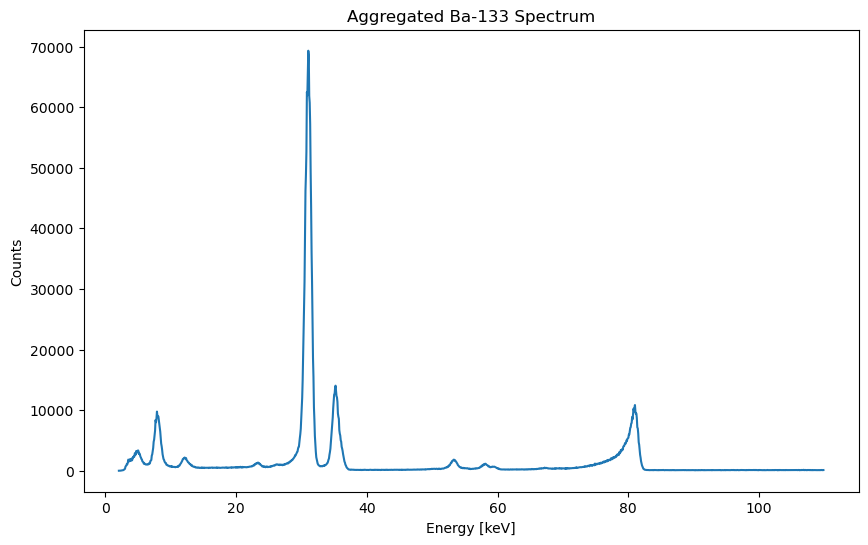

In [6]:
# Read in the data. 
ba133_file = data_dir / "aggregated_ba133_data_1kevto110kev_allpix_single_events_bl_sub.npz"
ba133_data = np.load(ba133_file)

# Plot to check. 
plt.figure(figsize=(10, 6))
plt.plot(ba133_data['energy'], ba133_data['flux'])
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')
plt.title('Aggregated Ba-133 Spectrum')
plt.show()

The next step is to identify the lines present in the spectrum to include in the model. The spectral lines from Ba-133 will be present, as will the CdTe escape lines. There will be XRF lines from Al and W (detector housing and components), Be, Fe (Be-alloy windows), Au, Ag, Pt, Pb (used in the construction of the Caliste-SO ASICs, including Pb solder). 

In [ ]:
# Perform the fit for the aggregated Ba133 spectrum. 

# Select the energy range for the fit. 
ba133_idx = np.where((ba133_data['energy'] > 4) & (ba133_data['energy'] < 85))
ba133_x = ba133_data['energy'][ba133_idx]
ba133_y = ba133_data['flux'][ba133_idx]

# Identify lines in the spectrum to include in the model. 
mus_gauss = [
    # Ba-133 lines
    79.6142, # Ba-133 gamma
    67.5,    # Pt La1
    
    # 60 keV region; weaker lines have been consolidated.
    59.49,   # Consolidated Compton structure

    59.7,    # Compton shoulder 
    59.3,    # 
    60.1,    # 
    58.016,  # CdTe escape (from 81 keV line)
    57.826,  # Cd Ka escape (from 81 keV line)
    56.4,    # Cd Ka escape (from 79.6 keV line)
    
    # 53 keV region - main line + structure
    53.1622, # Ba-133 gamma
    52.9,    # CdTe escape line
    52.2,    # Compton Shoulder
    51.5,    # Compton Shoulder
    
    # Ba-133 lines
    36.432,  # Consolidated Ba Kb region (was 36.5 and 35.9)
    35.553,  # Ba Kb1
    34.7,    # 
    34.0,    # 
    
    # Ba K-shell transitions
    30.9731, # Ba Ka1
    30.6254, # Ba Ka2
    30.996,  # Te Kb1
    30.344,  # Te Ka2 
    
    # CdTe lines
    29.7884, # Te Kb1
    28.0,    # 
    27.7,    # 
    26.3594, # Te Ka1
    26.1111, # Te Ka2
    26.8,    # Te Ka escape
    26.5212, # CdTe escape line
    25.8,    # Cd Kb2
    25.2,    # Cd Kb2
    24.5,    # CdTe escape
    23.0,    # Cd Ka1
    23.4,    # Cd Ka1
    22.6,    # Cd Ka2
    22.0,    # Cd Ka2
    
    # Low energy structure
    20.5,    # W escape
    19.8,    #
    18.5,    # 
    17.0,    # 
    15.430,  # Au Lg1
    13.880,  # Pb Lb2
    13.382,  # Au Lb2
    12.100,  # W Lg2
    12.7283, # CdTe escape
    11.442,  # Au Lb1
    9.713,   # Au La1
    7.582,   # CdTe escape
    7.9911,  # CdTe escape
    6.404,   # Fe Ka1
    6.391,   # Fe Ka2
    5.531,   # Ba Lb2
    5.156,   # Ba L-shell
    4.467355,# Ba La1
    4.3321,  # CdTe escape 
]

# Initial guesses for the amplitudes
amps_gauss = [
    # Ba-133 lines
    40.,     
    500.,    
    
    # 60 keV region; weaker lines have been consolidated.
    500.,    # 59.49 (combined 61.2 + 60.8: 300 + 200 = 500)
    800.,    # 59.7
    400.,    # 59.3
    200.,    # 60.1
    600.,    # 58.016
    300.,    # 57.826
    
    # 53 keV region
    1500.,   # 56.4 
    1500.,   # Ba 53.2
    800.,    # 52.9
    400.,    # 52.2
    400.,    # 51.5
    
    # Ba-133 lines
    600.,    # 36.432 (combined 36.5 + 35.9: 200 + 400 = 600)
    10000.,  # Ba Kb1
    800.,    # 34.7
    400.,    # 34.0
    
    # Ba K-shell transitions
    80000.,  # Ba Ka1
    20000.,  # Ba Ka2
    1000.,   # Te Kb1
    500.,    # Te Ka2
    
    # CdTe lines
    200.,    # Te Kb1
    300.,    # 28.0
    150.,    # 27.7
    1200.,   # Te Ka1
    800.,    # Te Ka2
    200.,    # Te Ka escape
    1000.,   # CdTe escape
    400.,    # Cd Kb2
    200.,    # Cd Kb2
    300.,    # CdTe escape
    1200.,   # Cd Ka1
    600.,    # Cd Ka1
    300.,    # Cd Ka2
    200.,    # Cd Ka2
    
    # Low energy structure
    200.,    # W escape
    150.,    # 
    100.,    # 
    80.,     # 
    60.,     # Au Lg1
    100.,    # Pb Lb2
    150.,    # Au Lb2
    1000.,   # W Lg2
    1500.,   # CdTe escape
    800.,    # Au Lb1
    200.,    # Au La1
    100.,    # CdTe escape
    6000.,   # CdTe escape
    8000.,   # Fe Ka1
    400.,    # Fe Ka2
    300.,    # Ba Lb2
    2000.,   # Ba L-shell
    3000.,   # Ba La1
    100.,    # CdTe escape
]

mus_cb      = [80.998, 53.16, 35.053]  # Ba-133 Y lines
amps_cb     = [12000., 2000., 15000.]
alphas_cb   = [0.35, 0.5, 1.0]
ns_cb       = [2.0, 2.0, 2.0]

config = {
    "background_type": "enhanced",  # Most flexible background
    "n_gauss": len(mus_gauss), 
    "n_cb": len(mus_cb), 
    "link_sigma": True
}

# Initialize parameters. 
# Initial guesses for the background (exp + polynomial + step) and ENC.
p0 = []
p0 += [350.0, 16.0, 50.0, -0.5, 0.01, 200.0, 45.0, 3.0]  # model the step at 45 keV
p0 += [94.0]  # ENC

# Initialize the Gaussian fits. 
for A, mu in zip(amps_gauss, mus_gauss):
    p0 += [A * 0.8, mu]

# Initialize the CrystalBall fits. 
for A, mu, alpha, n in zip(amps_cb, mus_cb, alphas_cb, ns_cb):
    p0 += [A * 0.8, mu, alpha, n]

p0 = np.array(p0)

# Define the parameter bounds.
n_params = len(p0)
lower = -np.inf * np.ones(n_params)
upper = np.inf * np.ones(n_params)

# Bounds for the background.
lower[0:8] = [300, 10., 20., -5.0, -0.1, 0, 30, 1.0]
upper[0:8] = [500., 25.0, 200., 5.0, 0.1, 1000, 60, 10.0]

# Bounds for ENC (positive and realistic).
lower[8] = 90
upper[8] = 210.0

# Gaussian amplitudes >= 0
first_gauss_amp = 9  # offset in pars after background and ENC.
for i in range(config["n_gauss"]):
    lower[first_gauss_amp + 2*i] = 0.

# Crystal Ball amplitudes, alpha, n bounds.
idx_cb_start = first_gauss_amp + 2 * config["n_gauss"]
alpha_min, alpha_max = 0.3, 4.5
n_min, n_max = 0.5, 4.5
for i in range(config["n_cb"]):
    print(f'CB {i}: .......')
    amp_i = idx_cb_start + 4*i
    alpha_i = amp_i + 2
    n_i = amp_i + 3
    lower[amp_i] = 0.0
    lower[alpha_i], upper[alpha_i] = alpha_min, alpha_max
    lower[n_i], upper[n_i] = n_min, n_max

# Compute weights.
sigma_w = np.sqrt(np.maximum(ba133_y, 1.0)) # Poisson weights are 1 / sigma; sigma = sqrt(N).
weights = 1.0 / sigma_w

# Weighted least squares fit.  
res = least_squares(
    residuals,
    p0,
    args=(ba133_x, ba133_y, config, weights),
    bounds=(lower, upper),
    verbose=2,
    max_nfev=3000,   # maximum number of iterations.
    loss='soft_l1',  # Robust loss function.
    f_scale=0.1      # Robustness parameter.
)

print("\nFit success:", res.success)
print("Message:", res.message)
print("Fitted ENC = %.3f e⁻ RMS" % res.x[8])

print_fit_summary(p0, res.x, config)

CB 0: .......
CB 1: .......
CB 2: .......
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         1.5817e+03                                    2.45e+03    
       1              7         1.4719e+03      1.10e+02       5.15e-01       9.89e+02    
       2              9         1.4130e+03      5.89e+01       1.01e-01       4.94e+02    
       3             10         1.3775e+03      3.54e+01       1.57e-01       4.75e+02    
       4             11         1.3551e+03      2.24e+01       4.31e-01       8.96e+02    
       5             12         1.3116e+03      4.36e+01       4.79e-01       4.91e+02    
       6             13         1.2903e+03      2.13e+01       4.37e-01       9.19e+02    
       7             14         1.2365e+03      5.38e+01       4.72e-01       3.80e+02    
       8             16         1.2249e+03      1.16e+01       1.48e-01       4.91e+02    
       9             17         1.2014e+03      

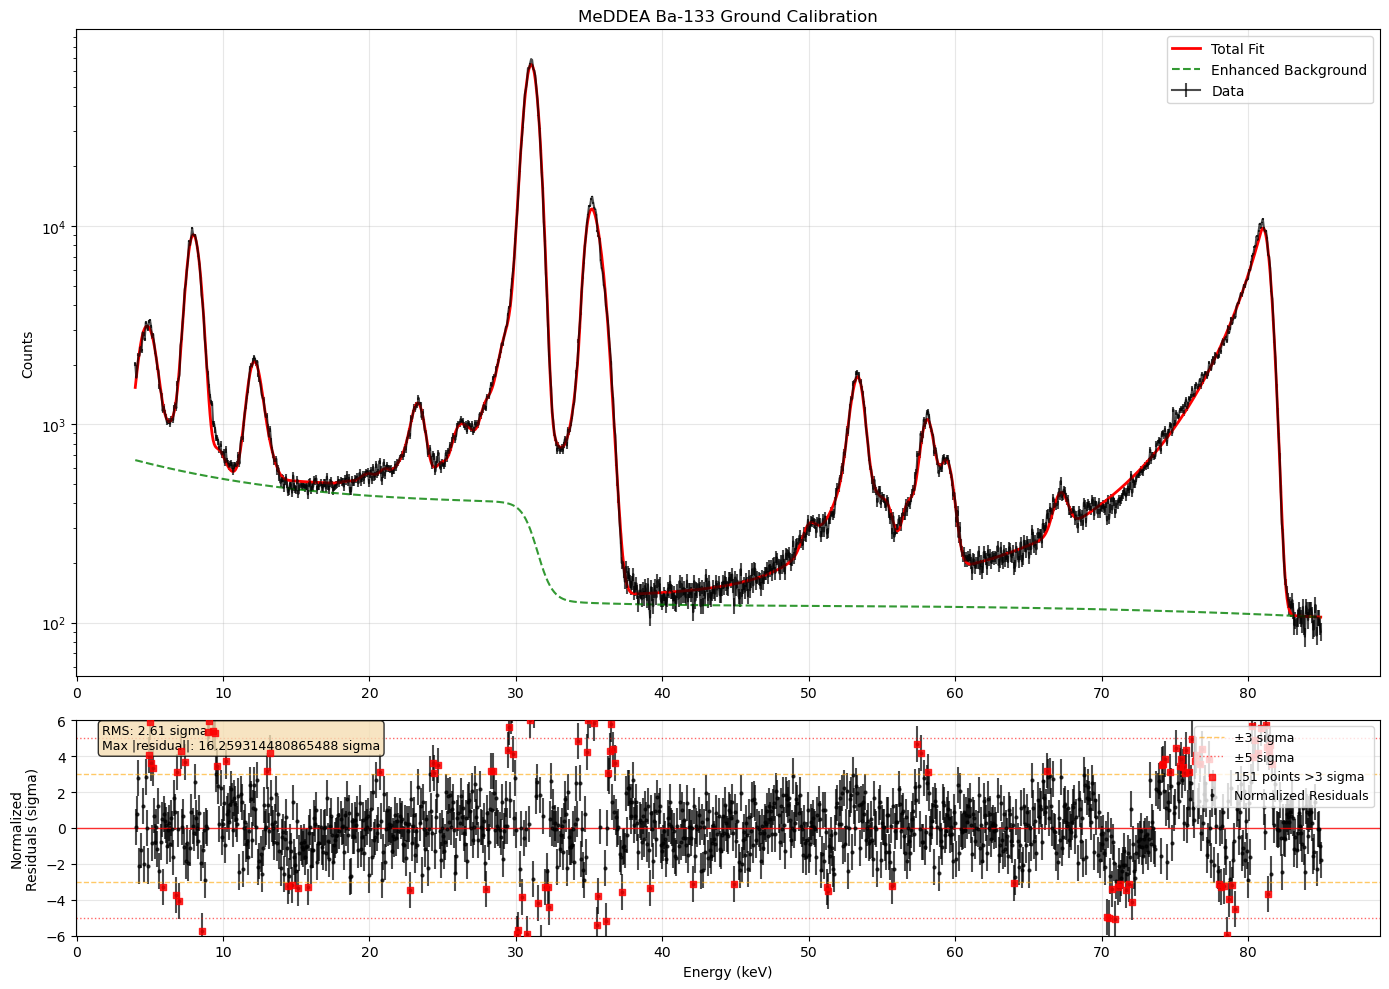


FIT QUALITY ANALYSIS
χ² = 7738.4709245082595
DOF = 998
Reduced χ² = 7.753978882272805
RMS residuals = 2.606602046326318 sigma

Residual Statistics:
Mean residual: 0.268 sigma
Std residual: 2.607 sigma
Max |residual|: 16.259314480865488 sigma
Points >3 sigma: 151 (13.398402839396628%)
Points >5 sigma: 62 (5.501330967169476%)


In [ ]:
# Plot the spectrum with residuals.
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), height_ratios=[3, 1])

# Plot the log-scale spectrum on axis 1 to assess the visual quality of the fit. 
ax1.errorbar(ba133_x, ba133_y, yerr=ba133_y**0.5, label="Data", color='k', alpha=0.7, markersize=1)
model_total = composite_model(ba133_x, res.x, config)
ax1.plot(ba133_x, model_total, "-r", lw=2.0, label="Total Fit")

bg_component = enhanced_background(ba133_x, *res.x[:8])
ax1.plot(ba133_x, bg_component, "--g", lw=1.5, alpha=0.8, label="Enhanced Background")

ax1.set_ylabel("Counts")
ax1.set_yscale('log')
ax1.set_title("MeDDEA Ba-133 Ground Calibration")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot the residuals plot on axis 2. 
residuals_raw = ba133_y - model_total
residuals_norm = residuals_raw / np.sqrt(np.maximum(ba133_y, 1.0))  # Normalized residuals

ax2.errorbar(ba133_x, residuals_norm, yerr=1.0, fmt='o', color='k', alpha=0.7, 
             markersize=2, capsize=0, label='Normalized Residuals')

# Add reference lines
ax2.axhline(y=0, color='red', linestyle='-', linewidth=1, alpha=0.8)
ax2.axhline(y=3, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='±3 sigma')
ax2.axhline(y=-3, color='orange', linestyle='--', linewidth=1, alpha=0.6)
ax2.axhline(y=5, color='red', linestyle=':', linewidth=1, alpha=0.6, label='±5 sigma')
ax2.axhline(y=-5, color='red', linestyle=':', linewidth=1, alpha=0.6)

# Format residuals plot
ax2.set_xlabel("Energy (keV)")
ax2.set_ylabel("Normalized\nResiduals (sigma)")
ax2.set_ylim(-6, 6)  # Show +/-6 sigma range
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', fontsize=9)

# Add residuals statistics as text
residuals_stats = f"RMS: {np.std(residuals_norm):.2f} sigma\n"
residuals_stats += f"Max |residual|: {np.max(np.abs(residuals_norm))} sigma"
ax2.text(0.02, 0.98, residuals_stats, transform=ax2.transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
         fontsize=9)

# Highlight regions with large residuals
large_residuals = np.abs(residuals_norm) > 3
if np.any(large_residuals):
    n_large = np.sum(large_residuals)
    ax2.scatter(ba133_x[large_residuals], residuals_norm[large_residuals], 
                color='red', s=20, marker='s', alpha=0.8, zorder=5,
                label=f'{n_large} points >3 sigma')
    ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# Print enhanced fit statistics
residuals_norm = (ba133_y - model_total) / np.sqrt(np.maximum(ba133_y, 1.0))
chi_squared = np.sum(residuals_norm**2)
dof = len(ba133_x) - len(res.x)
reduced_chi_sq = chi_squared / dof

print("FIT QUALITY ANALYSIS")
print(f"chi squared = {chi_squared}")
print(f"DOF = {dof}")
print(f"Reduced chi squared = {reduced_chi_sq}")
print(f"RMS residuals = {np.std(residuals_norm)} sigma")

# Additional residual statistics
print(f"\nResidual Statistics:")
print(f"Mean residual: {np.mean(residuals_norm)} sigma")
print(f"Std residual: {np.std(residuals_norm)} sigma")
print(f"Max |residual|: {np.max(np.abs(residuals_norm))} sigma")
print(f"Points >3 sigma: {np.sum(np.abs(residuals_norm) > 3)} ({100*np.sum(np.abs(residuals_norm) > 3)/len(residuals_norm)}%)")
print(f"Points >5 sigma: {np.sum(np.abs(residuals_norm) > 5)} ({100*np.sum(np.abs(residuals_norm) > 5)/len(residuals_norm)}%)")

Create the global fit plot (linear scale) to put into the instrument paper. 

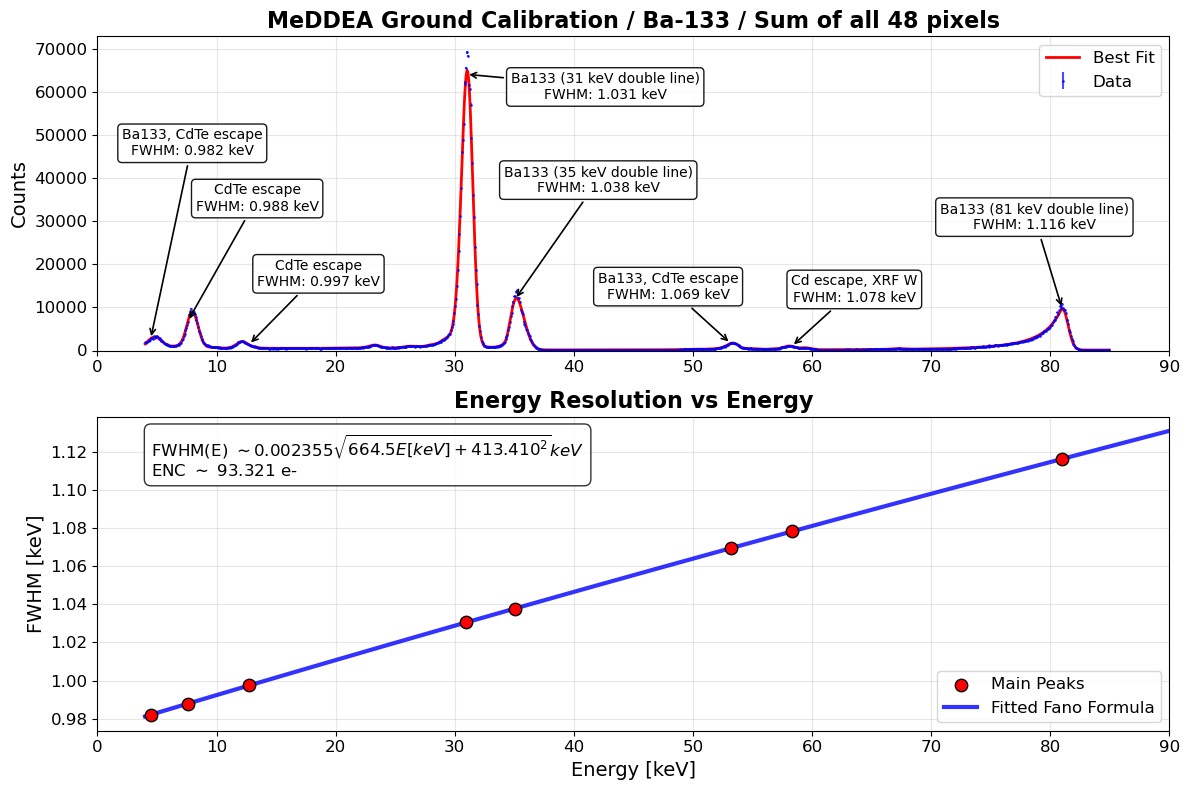


FWHM Summary from Fitted Model (ENC = 93.32055186696068 e⁻):
Peak Energy FWHM Resolution
Ba133, CdTe escape 4.467 0.9819988176591581 21.983407603742066%
CdTe escape 7.582 0.9878266508284346 13.02857624411019%
CdTe escape 12.7283 0.9973802306326963 7.8359264837621385%
Ba133 (31 keV double line) 30.9731 1.030536510343166 3.3271984733306197%
Ba133 (35 keV double line) 35.053 1.0378059990941992 2.9606766870002548%
Ba133, CdTe escape 53.1622 1.0694763836623016 2.0117233366232052%
Cd escape, XRF W 58.3 1.078292280527732 1.8495579425861612%
Ba133 (81 keV double line) 80.998 1.1164067110969111 1.3783139226856356%

Fit Quality:
   chi squared = 7738.4709245082595
   DOF = 998
   Reduced χ² = 7.753978882272805
   RMS residuals = 2.606602046326318


In [ ]:
# Extract the FWHM parameters from the fit.
def calculate_fwhm_from_fitted_enc(energy, fitted_enc):
    """
    Calculate FWHM directly using the fitted ENC and the fano_sigma function.
    All peaks use the same formula, because link_sigma = True.
    """
    sigma = fano_sigma(energy, fitted_enc)
    fwhm = 2.355 * sigma
    return fwhm

# Extract the ENC from the fit. 
fitted_enc = res.x[8]

# Identify the main peaks (Ba-133, CdTe escape) for annotation.
main_peaks = [
    (4.467, "Ba133, CdTe escape"),
    (7.582, "CdTe escape"), 
    (12.7283, "CdTe escape"),
    (30.9731, "Ba133 (31 keV double line)"), # Ba Ka1
    (35.053, "Ba133 (35 keV double line)"),  # Ba Kb1 
    (53.1622, "Ba133, CdTe escape"),         # Ba 53 keV line
    (58.3, "Cd escape, XRF W"),              # Escape line
    (80.998, "Ba133 (81 keV double line)"), # Crystal Ball peak
]

# Calculate FWHM for each peak. 
peak_energies = []
peak_fwhms = []
peak_labels = []

for energy, label in main_peaks:
    fwhm = calculate_fwhm_from_fitted_enc(energy, fitted_enc)
    peak_energies.append(energy)
    peak_fwhms.append(fwhm)
    peak_labels.append(label)

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
 
ax1.errorbar(ba133_x, ba133_y, yerr=np.sqrt(ba133_y), label="Data", color='blue', alpha=0.7, 
            markersize=1, fmt='o', capsize=0)
model_total = composite_model(ba133_x, res.x, config)
ax1.plot(ba133_x, model_total, "-", color='red', lw=2.0, label="Best Fit")

# Manually position the annotations to avoid overlap. 
annotation_configs = [
    (30, 130, 'center', 'bottom'),  # 4.7 keV
    (50, 77.5, 'center', 'bottom'), # 7.7 keV  
    (50, 40, 'center', 'bottom'),   # 11.9 keV
    (100, -20, 'center', 'bottom'), # 30.9 keV
    (60, 75, 'center', 'bottom'),   # 35.0 keV
    (-45, 30, 'center', 'bottom'),  # 53.2 keV
    (45, 30, 'center', 'bottom'),   # 58.0 keV
    (-20, 55, 'center', 'bottom'),  # 81.0 keV
]

for i, (energy, label) in enumerate(main_peaks):
    # Find peak height in model for annotation.
    peak_idx = np.argmin(np.abs(ba133_x - energy))
    if peak_idx < len(model_total):
        peak_height = model_total[peak_idx]
        fwhm = peak_fwhms[i]
        
        # Get positioning config.
        if i < len(annotation_configs):
            x_off, y_off, ha, va = annotation_configs[i]
        else:
            x_off, y_off, ha, va = (0, 30, 'center', 'bottom')
        
        # Create annotation text.
        annotation_text = f'{label}\nFWHM: {fwhm:.3f} keV'
        
        # Add annotation
        ax1.annotate(annotation_text,
                   xy=(energy, peak_height),
                   xytext=(x_off, y_off),
                   textcoords='offset points',
                   ha=ha, va=va,
                   fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', 
                            facecolor='white', 
                            alpha=0.9, 
                            edgecolor='black'),
                   arrowprops=dict(arrowstyle='->', 
                                 color='black', 
                                 lw=1.2))

ax1.set_ylabel("Counts", fontsize=14)
ax1.set_ylim(bottom=0)
ax1.set_xlim(0, 90)
ax1.tick_params(axis='both', which='major', labelsize=12)
ax1.set_title("MeDDEA Ground Calibration / Ba-133 / Sum of all 48 pixels", 
             fontsize=16, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Bottom plot: FWHM vs Energy
ax2.scatter(peak_energies, peak_fwhms, color='red', s=80, zorder=5, 
           label='Main Peaks', edgecolor='black')

# Plot Fano resolution curve
energy_range = np.linspace(4, 90, 100)
fwhm_curve = [calculate_fwhm_from_fitted_enc(E, fitted_enc) for E in energy_range]
ax2.plot(energy_range, fwhm_curve, 'b-', lw=3, label='Fitted Fano Formula', alpha=0.8)

# Optional: Plot Fano limit (statistical only, no electronic noise)
fano_limit = []
Eps = 4.43e-3  # eV per e-h pair converted to keV
F = 0.15       # Fano factor
for E in energy_range:
    sigma_stat = np.sqrt(F * E * Eps)
    fwhm_limit = 2.355 * sigma_stat
    fano_limit.append(fwhm_limit)
#ax2.plot(energy_range, fano_limit, 'k--', lw=2, label='Fano Limit', alpha=0.7)

# Add text box with the derived Fano formula.
formula_textbox = rf"FWHM(E) $\sim {2.355/1000}\sqrt{{{4.43*0.15*1000}E [keV] + {4.43*fitted_enc:.3f}^2}} keV$" + f"\nENC $\sim$ {fitted_enc:.3f} e-"

ax2.text(0.05, 0.95, formula_textbox, 
         transform=ax2.transAxes, 
         fontsize=12, 
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.8))

ax2.set_xlabel("Energy [keV]", fontsize=14)
ax2.set_ylabel("FWHM [keV]", fontsize=14)
ax2.set_xlim(0, 90)
ax2.tick_params(axis='both', which='major', labelsize=12)
ax2.set_title("Energy Resolution vs Energy", fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=12)
ax2.tick_params(axis='both', which='major', labelsize=12) 

plt.tight_layout()
plt.show()

# Print detailed FWHM summary
print(f"\nFWHM Summary from Fitted Model (ENC = {fitted_enc} e⁻):")
print(f"{'Peak'} {'Energy'} {'FWHM'} {'Resolution'}")

for energy, fwhm, label in zip(peak_energies, peak_fwhms, peak_labels):
    resolution = (fwhm / energy) * 100
    print(f"{label} {energy} {fwhm} {resolution}%")

# Print fit statistics
residuals_norm = (ba133_y - model_total) / np.sqrt(ba133_y)
chi_squared = np.sum(residuals_norm**2)
dof = len(ba133_x) - len(res.x)
reduced_chi_sq = chi_squared / dof

print(f"\nFit Quality:")
print(f"   chi squared = {chi_squared}")
print(f"   DOF = {dof}")
print(f"   Reduced χ² = {reduced_chi_sq}")
print(f"   RMS residuals = {np.std(residuals_norm)}")